# Real Mars DEM Analysis: Jezero Crater

This notebook applies the p-adic fractal analysis framework to real Mars elevation data.
We analyze the Jezero crater CTX DEM and identify high-complexity terrain regions.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
padic_path = '/Volumes/Fangorn/padic_fractal_analysis/src'
sys.path.insert(0, padic_path)

from padic import preprocessing, pyramid, fractal_density, visualization

DATA_DIR = Path.cwd().parent / 'data'
NOTEBOOKS_DIR = Path.cwd()

dem_files = list(DATA_DIR.glob('*.tif'))
print(f"Found {len(dem_files)} DEM files")
for f in dem_files:
    print(f"  {f.name}: {f.stat().st_size / 1e6:.1f} MB")

Found 1 DEM files
  JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif: 9.7 MB


## Part 1: Load and Explore Mars DEM Data

In [2]:
if dem_files:
    DEM_FILE = dem_files[0]
    dem, metadata = preprocessing.load_dem(str(DEM_FILE))
    
    print(f"Loaded: {DEM_FILE.name}")
    print(f"Shape: {dem.shape}")
    print(f"Min: {np.nanmin(dem):.2f} m")
    print(f"Max: {np.nanmax(dem):.2f} m")
    print(f"Mean: {np.nanmean(dem):.2f} m")
    print(f"Std: {np.nanstd(dem):.2f} m")
else:
    print("No DEM files found")

Loaded: JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif
Shape: (1512, 1596)
Min: -2710.70 m
Max: -1515.54 m
Mean: -2356.87 m
Std: 267.75 m


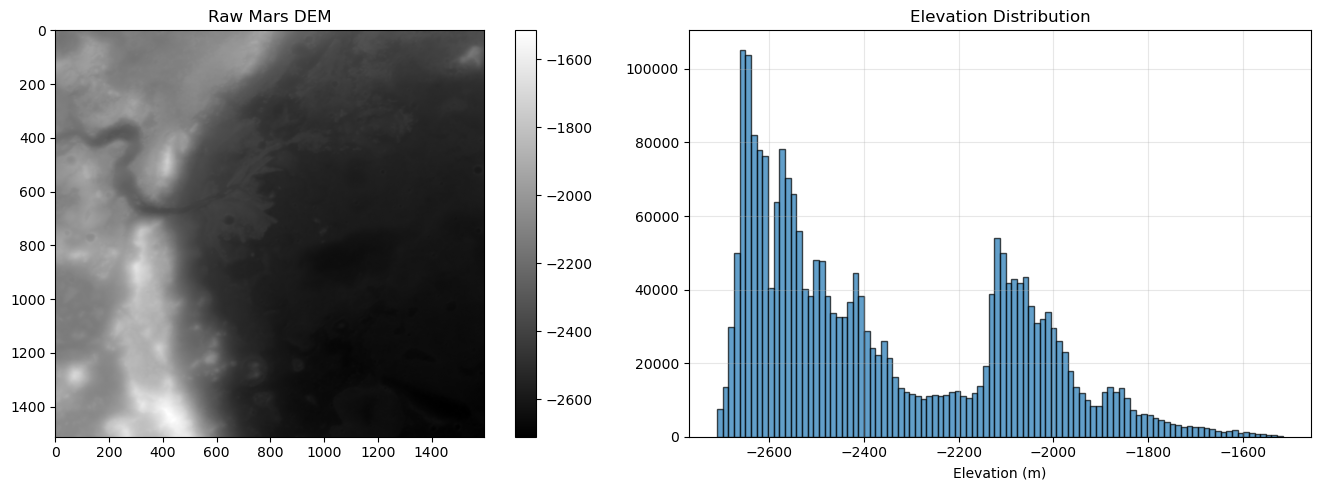

In [3]:
if dem is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im = axes[0].imshow(dem, cmap='gray')
    axes[0].set_title('Raw Mars DEM')
    plt.colorbar(im, ax=axes[0])
    
    valid = dem[~np.isnan(dem)]
    axes[1].hist(valid, bins=100, edgecolor='black', alpha=0.7)
    axes[1].set_title('Elevation Distribution')
    axes[1].set_xlabel('Elevation (m)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Part 2: Preprocess Mars DEM

In [4]:

print("Preprocessing DEM...")
dem_clean, stats = preprocessing.preprocess_dem(
    dem, 
    fill_depressions_flag=True,
    remove_jitter_flag=True,
    normalize_flag=True
)
print(f"Done. Cleaned stats: min={np.nanmin(dem_clean):.3f}, max={np.nanmax(dem_clean):.3f}")

Preprocessing DEM...
Done. Cleaned stats: min=-1.321, max=3.140


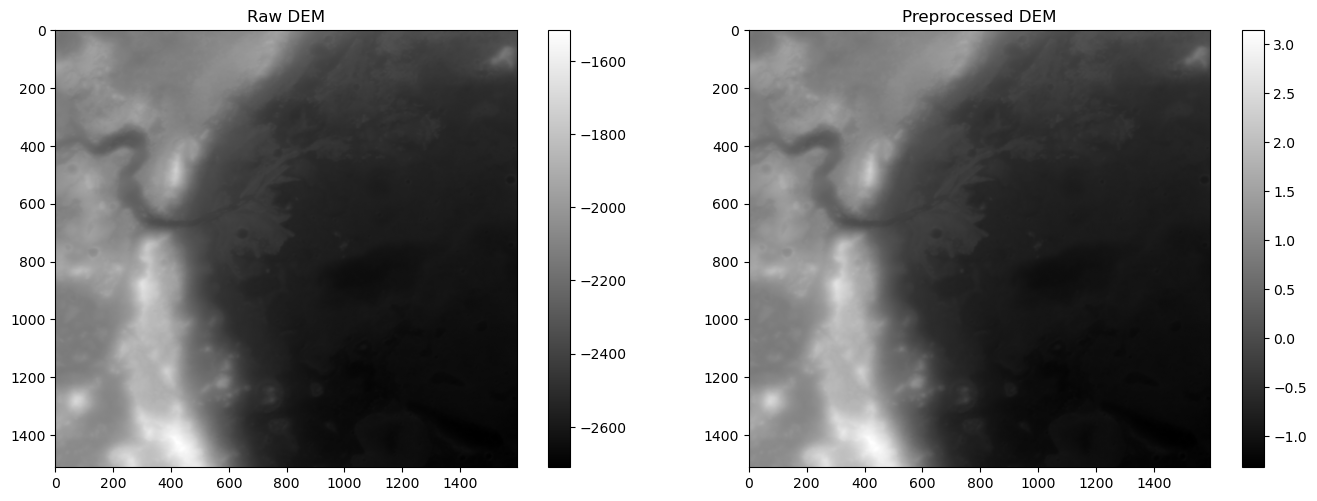

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(dem, cmap='gray')
axes[0].set_title('Raw DEM')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(dem_clean, cmap='gray')
axes[1].set_title('Preprocessed DEM')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Part 3: Build Hierarchical Multi-Scale Structures

In [7]:

print("Building Gaussian pyramid...")
pyr = pyramid.GaussianPyramid(dem_clean, num_levels=None)

print(f"Pyramid has {len(pyr.levels)} levels")
for i, level in enumerate(pyr.levels[:5]):
    print(f"  Level {i}: {level.shape}")

total_size = sum(l.size for l in pyr.levels)
base_size = pyr.levels[0].size
ratio = total_size / base_size
print(f"Storage ratio: {ratio:.3f}x")

Building Gaussian pyramid...
Pyramid has 11 levels
  Level 0: (1512, 1596)
  Level 1: (756, 798)
  Level 2: (378, 399)
  Level 3: (189, 200)
  Level 4: (95, 100)
Storage ratio: 1.333x


## Part 4: Compute Fractal Density Map

In [8]:

print("Computing fractal density...")
calc = fractal_density.FractalDensityCalculator(dem_clean, base_resolution=1.0)
density = calc.compute_fast_variance_based_density()

print(f"Density computed")
print(f"  Min: {np.nanmin(density):.3f}")
print(f"  Max: {np.nanmax(density):.3f}")
print(f"  Mean: {np.nanmean(density):.3f}")
print(f"  Std: {np.nanstd(density):.3f}")

Computing fractal density...
Density computed
  Min: 0.009
  Max: 1.000
  Mean: 0.484
  Std: 0.280


High-complexity: 25.0% of terrain


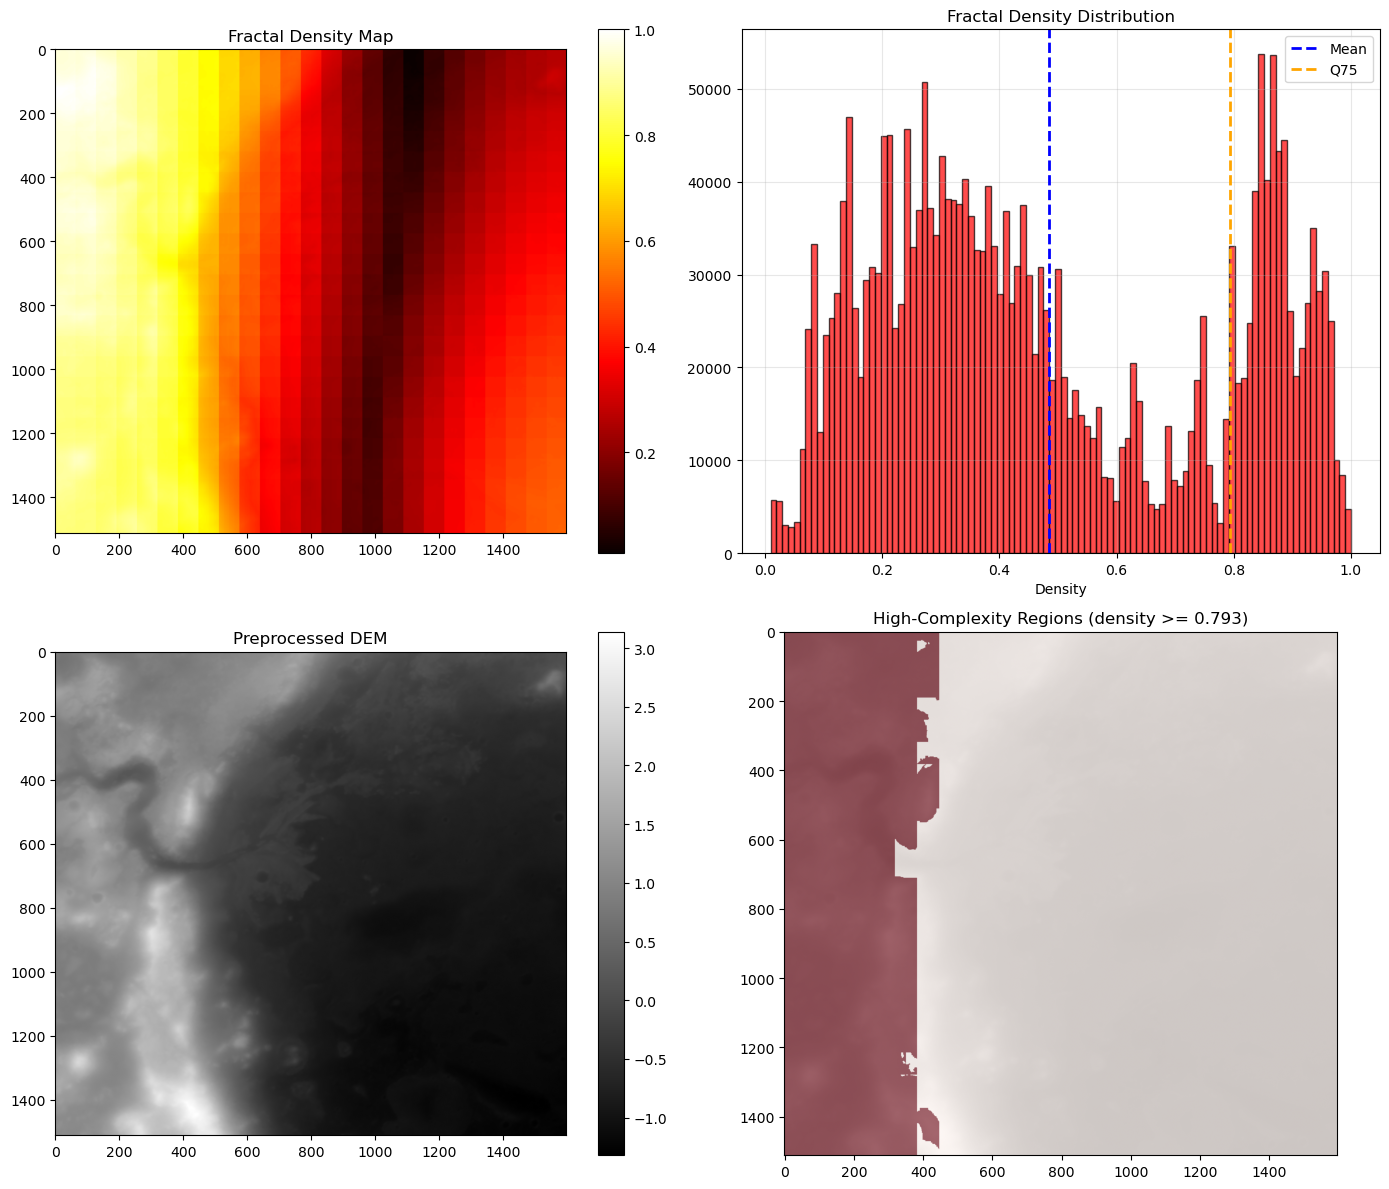

In [9]:

valid_density = density[~np.isnan(density)]
q25, q75 = np.percentile(valid_density, [25, 75])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0, 0].imshow(density, cmap='hot')
axes[0, 0].set_title('Fractal Density Map')
plt.colorbar(im1, ax=axes[0, 0])

axes[0, 1].hist(valid_density, bins=100, edgecolor='black', alpha=0.7, color='red')
axes[0, 1].axvline(np.nanmean(density), color='blue', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].axvline(q75, color='orange', linestyle='--', linewidth=2, label='Q75')
axes[0, 1].set_title('Fractal Density Distribution')
axes[0, 1].set_xlabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

im2 = axes[1, 0].imshow(dem_clean, cmap='gray')
axes[1, 0].set_title('Preprocessed DEM')
plt.colorbar(im2, ax=axes[1, 0])

high_complexity = density >= q75
axes[1, 1].imshow(dem_clean, cmap='gray', alpha=0.5)
axes[1, 1].imshow(high_complexity, cmap='Reds', alpha=0.6)
axes[1, 1].set_title(f'High-Complexity Regions (density >= {q75:.3f})')

pct_high = 100 * np.sum(high_complexity) / high_complexity.size
print(f"High-complexity: {pct_high:.1f}% of terrain")

plt.tight_layout()
plt.show()

## Part 5: Export Results as GeoTIFF

In [10]:
if dem is not None:
    output_dir = NOTEBOOKS_DIR.parent / 'results'
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / 'fractal_density_jezero.tif'
    
    try:
        exporter = visualization.GeoTIFFExporter()
        exporter.save_density_tiff(
            density,
            str(output_file),
            transform=metadata.get('transform'),
            crs=metadata.get('crs')
        )
        print(f"Exported to: {output_file.name}")
    except Exception as e:
        print(f"Export error: {e}")
        np.save(output_dir / 'fractal_density_jezero.npy', density)
        print(f"Saved to: fractal_density_jezero.npy")

Exported to: fractal_density_jezero.tif


## Part 6: Summary

In [11]:
if dem is not None:
    print("="*70)
    print("MARS DEM ANALYSIS SUMMARY: JEZERO CRATER")
    print("="*70)
    print(f"\n1. INPUT DATA")
    print(f"   File: {DEM_FILE.name}")
    print(f"   Size: {dem.shape[0]} x {dem.shape[1]} pixels")
    print(f"   Resolution: 20 m/pixel")
    print(f"\n2. PREPROCESSING")
    print(f"   Depression filling: Yes")
    print(f"   Jitter removal: Yes")
    print(f"   Normalization: Yes")
    print(f"\n3. HIERARCHICAL DECOMPOSITION")
    print(f"   Pyramid levels: {len(pyr.levels)}")
    print(f"   Storage ratio: {ratio:.3f}x")
    print(f"\n4. FRACTAL DENSITY")
    print(f"   Mean density: {np.nanmean(density):.3f}")
    print(f"   High-complexity: {pct_high:.1f}%")
    print(f"\n" + "="*70)

MARS DEM ANALYSIS SUMMARY: JEZERO CRATER

1. INPUT DATA
   File: JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif
   Size: 1512 x 1596 pixels
   Resolution: 20 m/pixel

2. PREPROCESSING
   Depression filling: Yes
   Jitter removal: Yes
   Normalization: Yes

3. HIERARCHICAL DECOMPOSITION
   Pyramid levels: 11
   Storage ratio: 1.333x

4. FRACTAL DENSITY
   Mean density: 0.484
   High-complexity: 25.0%



In [ ]:
d